In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("taxis")

df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[us]
 1   dropoff          6433 non-null   datetime64[us]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   str           
 9   payment          6389 non-null   str           
 10  pickup_zone      6407 non-null   str           
 11  dropoff_zone     6388 non-null   str           
 12  pickup_borough   6407 non-null   str           
 13  dropoff_borough  6388 non-null   str           
dtypes: datetime64[us](2), float64(5), int64(1), str(6)


In [3]:
df.isnull().sum()

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

In [4]:
numerical_columns = df.select_dtypes(include=np.number).columns

for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()

C:\Users\acer\AppData\Local\Temp\ipykernel_12920\4095450360.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64

In [7]:
numerical_columns = df.select_dtypes(include=np.number).columns

for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()

C:\Users\acer\AppData\Local\Temp\ipykernel_12920\4095450360.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64

In [6]:
df["pickup"] = pd.to_datetime(df["pickup"])

df["pickup"].dtype

dtype('<M8[us]')

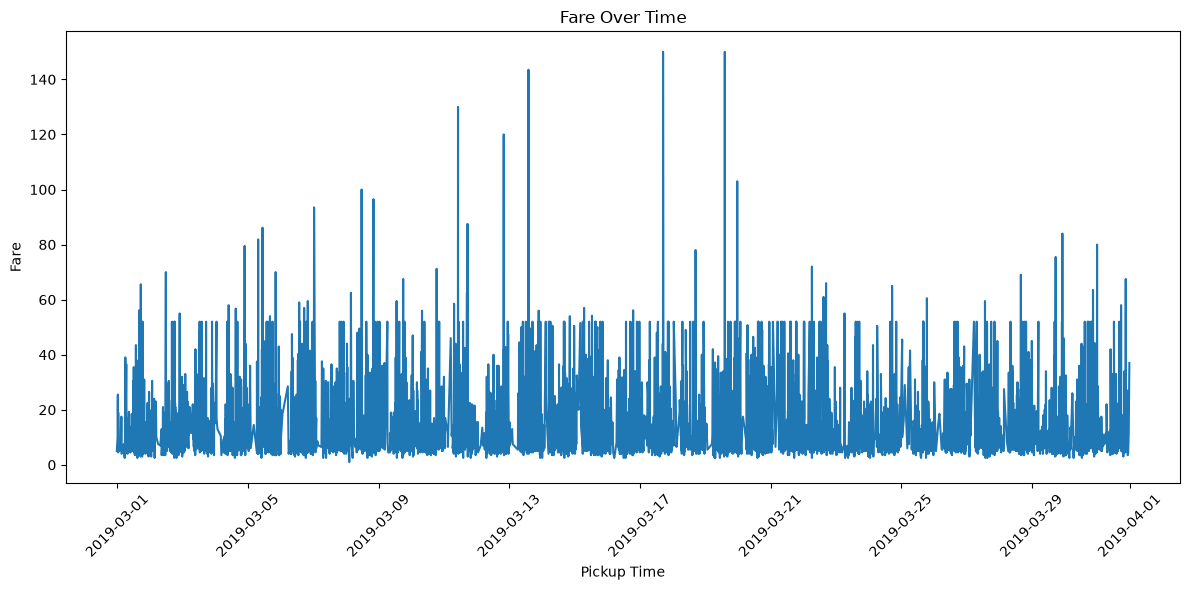

In [8]:
# Sort the data by pickup time
df = df.sort_values("pickup")

# Create a line chart
plt.figure(figsize=(12, 6))

plt.plot(df["pickup"], df["fare"])

plt.title("Fare Over Time")
plt.xlabel("Pickup Time")
plt.ylabel("Fare")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

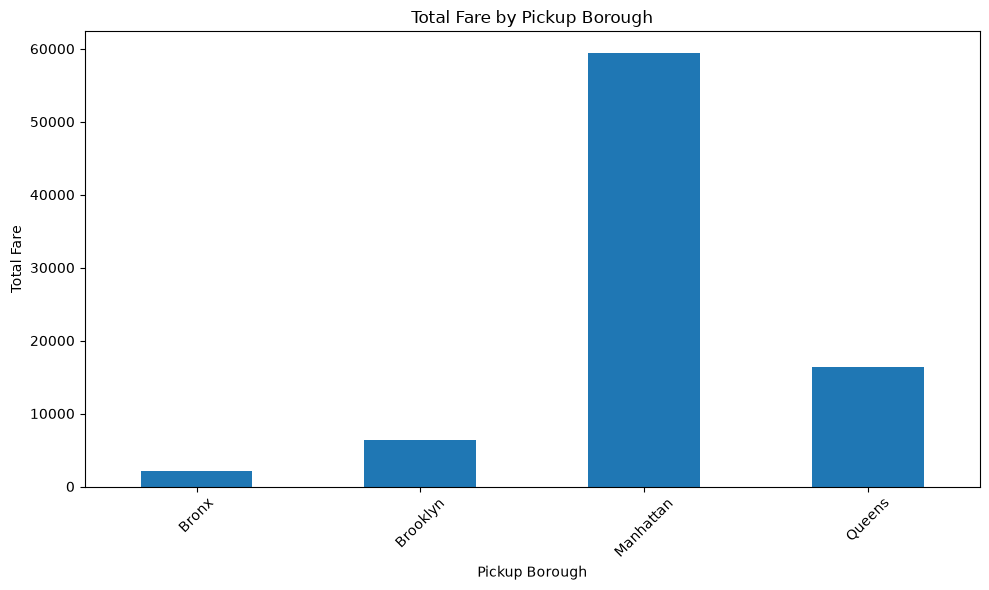

In [9]:
borough_fare = df.groupby("pickup_borough")["fare"].sum()

plt.figure(figsize=(10, 6))

borough_fare.plot(kind="bar")

plt.title("Total Fare by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

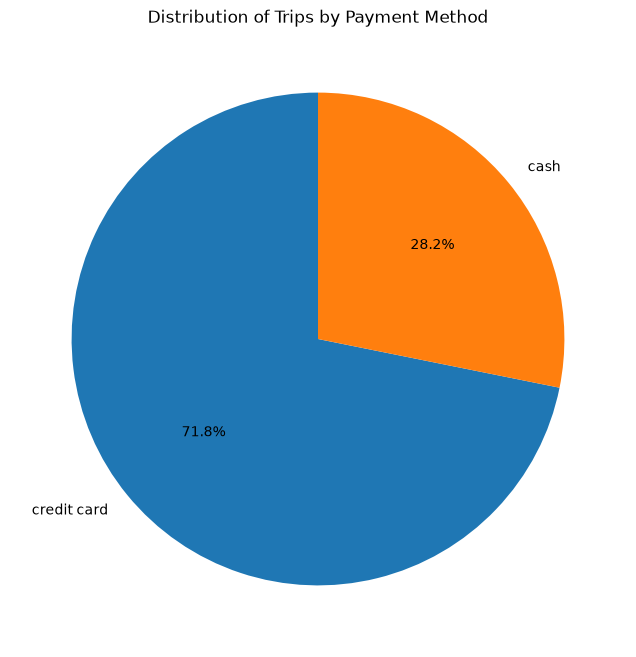

In [10]:
payment_counts = df["payment"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Trips by Payment Method")
plt.show()

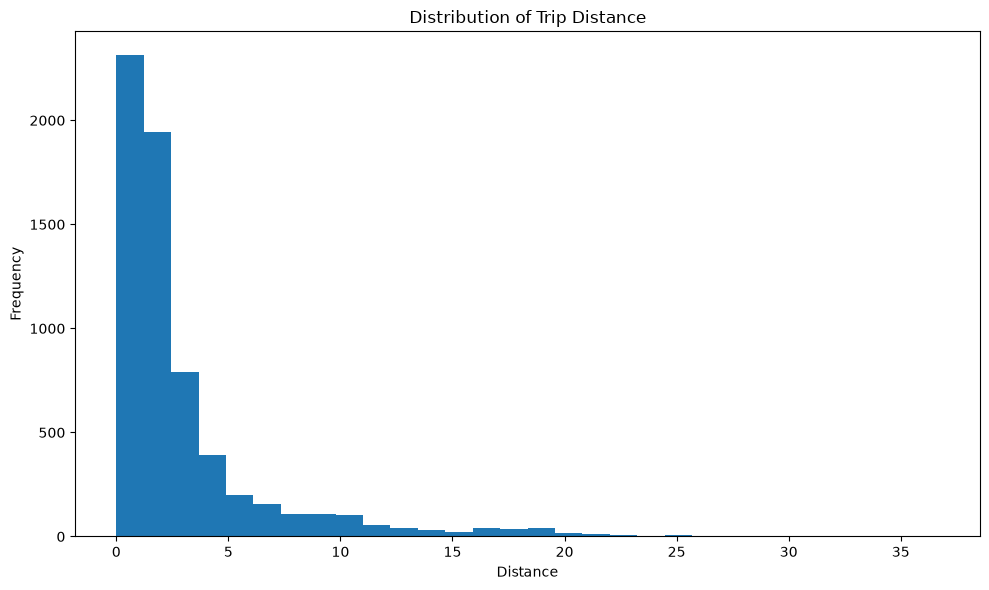

In [11]:
plt.figure(figsize=(10, 6))

plt.hist(df["distance"], bins=30)

plt.title("Distribution of Trip Distance")
plt.xlabel("Distance")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

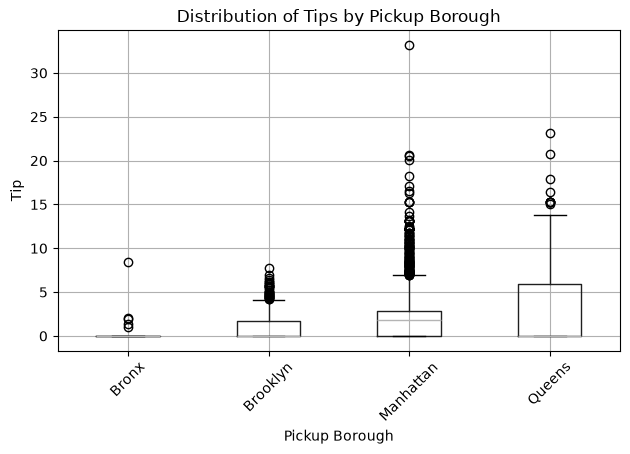

In [12]:
plt.figure(figsize=(12, 6))

df.boxplot(
    column="tip",
    by="pickup_borough"
)

plt.title("Distribution of Tips by Pickup Borough")
plt.suptitle("")
plt.xlabel("Pickup Borough")
plt.ylabel("Tip")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

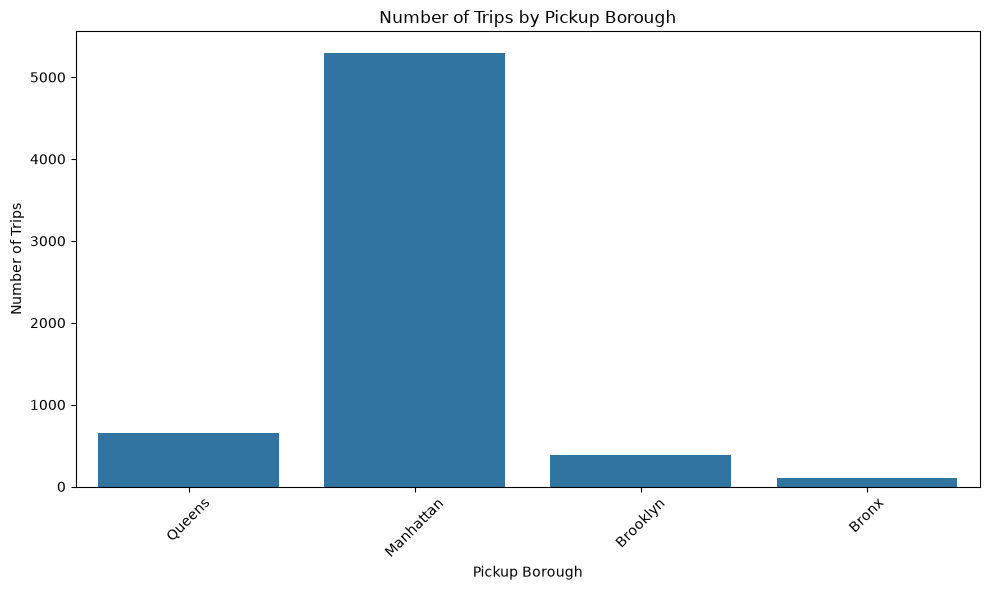

In [13]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="pickup_borough"
)

plt.title("Number of Trips by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Number of Trips")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

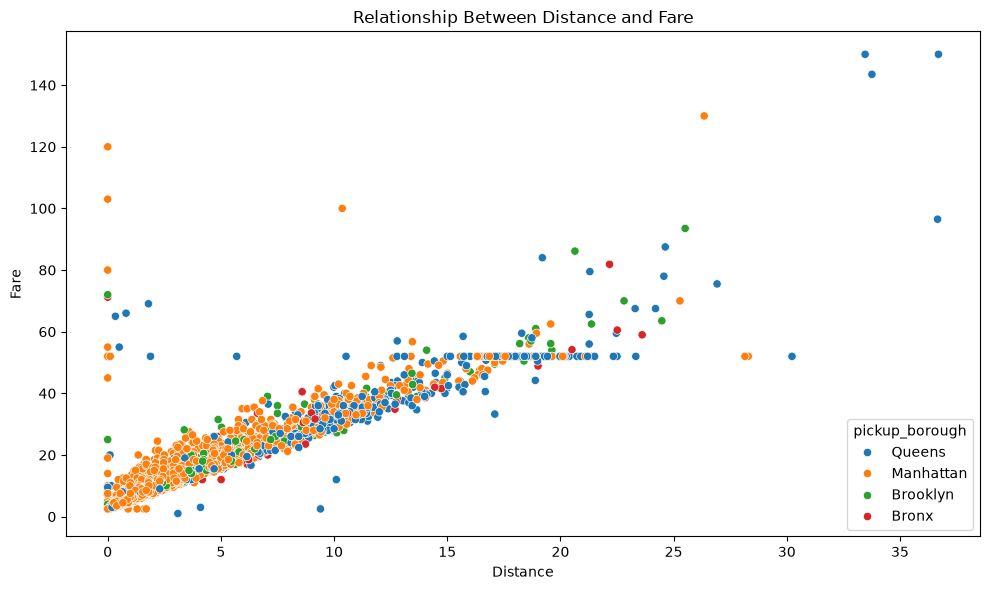

In [14]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="distance",
    y="fare",
    hue="pickup_borough"
)

plt.title("Relationship Between Distance and Fare")
plt.xlabel("Distance")
plt.ylabel("Fare")

plt.tight_layout()
plt.show()

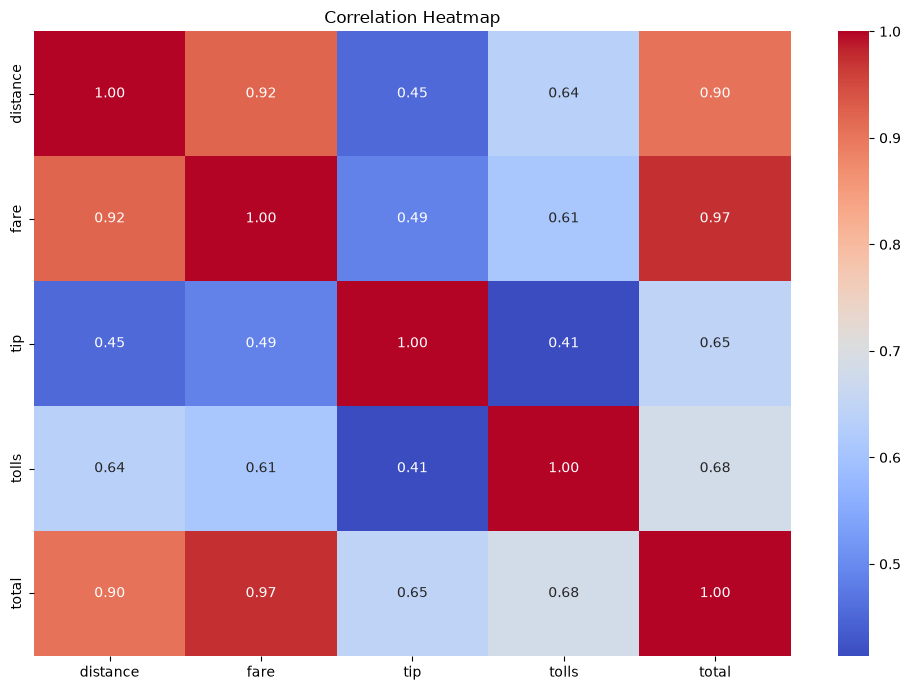

In [15]:
numeric_data = df[
    ["distance", "fare", "tip", "tolls", "total"]
]

correlation = numeric_data.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()